In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
from scipy import stats
import math
import pandas as pd

plt.style.use("fivethirtyeight")

In [13]:
# Задаем выборку

n = 100
# θ = np.random.r
θ = 1
sample = np.random.uniform(low=θ, high=2*θ, size=n)

sample

array([1.82793513, 1.66508857, 1.60267273, 1.50580335, 1.52402522,
       1.76170388, 1.01906733, 1.55283257, 1.19229467, 1.75600437,
       1.56023177, 1.67363442, 1.68804403, 1.40372985, 1.56851341,
       1.89597124, 1.40947005, 1.58357171, 1.31057533, 1.78178647,
       1.24504471, 1.53909209, 1.33463859, 1.38259333, 1.80501005,
       1.21156276, 1.98799595, 1.27804111, 1.152424  , 1.77550453,
       1.1777741 , 1.38308946, 1.50252997, 1.75890694, 1.69179062,
       1.18980193, 1.6527401 , 1.18201176, 1.82524718, 1.72665116,
       1.34086472, 1.41331532, 1.44716109, 1.85740364, 1.73142358,
       1.30525651, 1.69963682, 1.17557628, 1.94203576, 1.27872518,
       1.21457801, 1.83191611, 1.13376669, 1.79656158, 1.51324116,
       1.17697697, 1.93119161, 1.99559562, 1.51819147, 1.61834373,
       1.36640101, 1.04294249, 1.72864964, 1.4792889 , 1.47632259,
       1.18887763, 1.92405498, 1.05859117, 1.57771363, 1.92040156,
       1.46688057, 1.13432633, 1.84553859, 1.34835339, 1.30412

# Вычислим доверительные интервалы

In [3]:
β = 0.95

## Точный и асимптотический

### Точный

In [22]:
t1 = np.pow((1-β) / 2, 1 / n)
t2 = np.pow((1+β) / 2, 1 / n)
x_max = max(sample)

boundaries = [x_max / (1 + t2), x_max / (1 + t1)]
print(f"Доверительный интервал: [{boundaries[0]:.4f}, {boundaries[1]:.4f}]")
print(f"Длина: {(boundaries[1] - boundaries[0]):.4f}")

Доверительный интервал: [0.9979, 1.0162]
Длина: 0.0183


### Асимптотический

In [37]:
α1 = stats.moment(sample, 1)
α2 = stats.moment(sample, 2) 

t1 = stats.norm.ppf((1 - β) / 2)
t2 = stats.norm.ppf((1 + β) / 2)

θ_estimation = 2/3 * np.mean(sample)

boundaries2 = [θ_estimation + t1 * np.sqrt((4/9 * (α2-α1**2)) / n),
              θ_estimation + t2 * np.sqrt((4/9 * (α2-α1**2)) / n)]
print(f"Доверительный интервал: [{boundaries2[0]:.4f}, {boundaries2[1]:.4f}]")
print(f"Длина: {(boundaries2[1] - boundaries2[0]):.4f}")

Доверительный интервал: [0.9608, 1.0328]
Длина: 0.0720


## Бутстраповский доверительный интервал

In [41]:
N = 1000

h = (n + 1) * x_max / (2 * n + 1)
delta_series = np.zeros(shape=N) # для получения вариационного ряда Δ(i)
for i in range(N):
    bootstrap_sample = np.random.choice(sample, size=n)
    delta_series[i] = (n + 1) * np.max(bootstrap_sample) / (2 * n + 1) - h
delta_series = np.sort(delta_series)

κ1 = int(np.round((1-β) / 2 * N))
κ2 = int(np.round((1+β) / 2 * N))

Δκ1 = delta_series[κ1]
Δκ2 = delta_series[κ2]

boundaries3 = [h - Δκ2, h - Δκ1]
print(f"Доверительный интервал: [{boundaries3[0]:.4f}, {boundaries3[1]:.4f}]")
print(f"Длина: {(boundaries3[1] - boundaries3[0]):.4f}")


Доверительный интервал: [1.0028, 1.0297]
Длина: 0.0269


## Сравнение доверительных интервалов

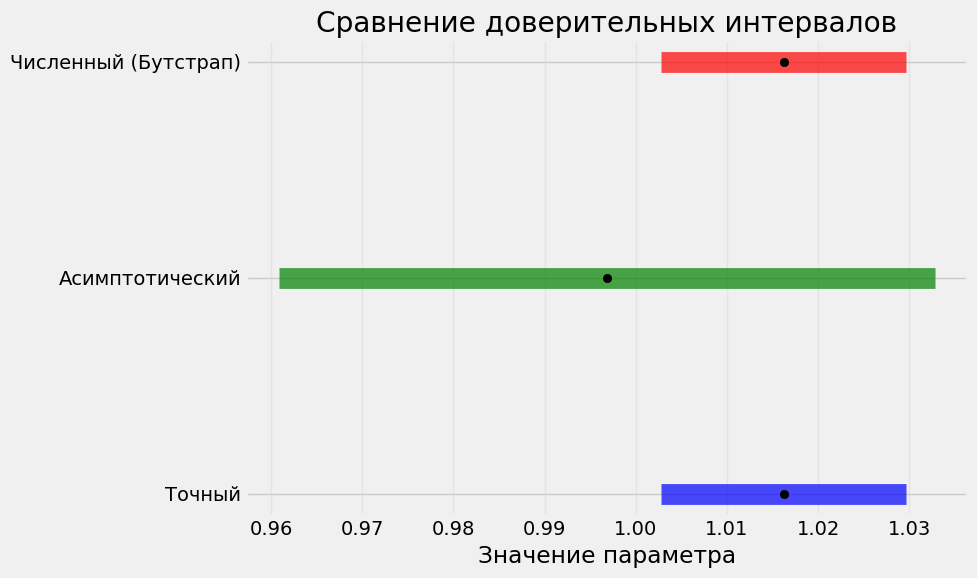

In [42]:
import matplotlib.pyplot as plt
import numpy as np


methods = ['Точный', 'Асимптотический', 'Численный (Бутстрап)']
lower_bounds = [boundaries[0], boundaries2[0], boundaries3[0]]
upper_bounds = [boundaries[1], boundaries2[1], boundaries3[1]]


fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(methods))

ax.hlines(y_pos, lower_bounds, upper_bounds,
           color=['blue', 'green', 'red'],
           linewidth=15, alpha=0.7)


centers = [(low + high) / 2 for low, high in zip(lower_bounds, upper_bounds)]
ax.scatter(centers, y_pos, color='black', zorder=5)


ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Значение параметра')
ax.set_title('Сравнение доверительных интервалов')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Вывод:
* Интервал, полученный с помощью непараметрического bootstrap, хорошо соответствует точному
* Доверительный интервал по асимптотическому методу получается завышенный